In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo

# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 16

In [2]:
DP = DP()
dps_df, model_1comp_dps, left_2comp_dps, right_2comp_dps = DP.extract_fits_data('./catalogs/0327_dps_test.fits')
cs_df, model_1comp_cs, left_2comp_cs, right_2comp_cs = DP.extract_fits_data('./catalogs/0327_nbcs_test.fits')

stellar_df = pd.read_csv('./catalogs/stellar_fits_catalog.csv')
dps_df = pd.merge(dps_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')
cs_df = pd.merge(cs_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')

dps_df.drop(columns=['MORPHTYPE', 'P_VALUE', 'BPT_1COMP'], inplace=True)
cs_df.drop(columns=['MORPHTYPE', 'P_VALUE', 'BPT_2COMP', 'DV_R', 'DV_L', 'SIGMA_L', 'SIGMA_R'], inplace=True)

In [3]:
delta_dv = dps_df['DV_R'] - dps_df['DV_L']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['SIGMA_R']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['SIGMA_L']**2 + resolution**2)
dps_df['delta_dv'] = delta_dv
dps_df['width_ratio'] = sigma_l / sigma_r

# robust_dps = dps_df[(dps_df['BPT_2comp']!=512)&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = dps_df[(dps_df['BPT_2COMP']!=512)&(dps_df['LOGM']!=0)]
robust_dps = robust_dps[(~robust_dps['width_ratio'].isnull())]
# robust_cs = cs_df[(cs_df['BPT_1comp']!=256)&(cs_df['VD_SL']!=0)&(cs_df['LOGM']!=0)]
robust_cs = cs_df[(cs_df['BPT_1COMP']!=256)&(cs_df['LOGM']!=0)]

In [4]:
dAGN_dp = robust_dps[robust_dps['BPT_2COMP']==32].copy()
print(len(dAGN_dp))
AGN_cs = robust_cs[robust_cs['BPT_1COMP']==16].copy()
print(len(AGN_cs))

206
443


In [5]:
model_1comp_dps = model_1comp_dps[dAGN_dp.index]
left_2comp_dps = left_2comp_dps[dAGN_dp.index]
right_2comp_dps = right_2comp_dps[dAGN_dp.index]
print(len(model_1comp_dps), len(left_2comp_dps), len(right_2comp_dps))


model_1comp_cs = model_1comp_cs[AGN_cs.index]
print(len(model_1comp_cs))

206 206 206
443


In [6]:
dAGN_dp['flux_ratio'] = [0] * len(dAGN_dp)

flux_ratio = []
for i in range(len(dAGN_dp)):
    flux_ratio.append(dAGN_dp['OIII5007_FLUX_2COMP_L'].iloc[i] / dAGN_dp['OIII5007_FLUX_2COMP_R'].iloc[i])
dAGN_dp['flux_ratio'] = flux_ratio


In [7]:
dAGN_dp = dAGN_dp[dAGN_dp['flux_ratio']!=0].copy()
print(len(dAGN_dp))

206


In [8]:
x = np.linspace(0.1, 10, 100)
# y = 0.005-(0.96*np.log10(x))
y = -np.log10(x)
y_outflow = 3*np.log10(x)
y_ = 1/3*np.log10(x)

In [9]:
from scipy import stats

data_x = np.log10(-dAGN_dp['DV_L']/dAGN_dp['DV_R'])
data_y = np.log10(dAGN_dp['flux_ratio'])

# remove NaN and inf values
valid_indices = np.isfinite(data_x) & np.isfinite(data_y) & (data_x > np.log10(0.1)) & (data_x < np.log10(10)) & (data_y > np.log10(0.1)) & (data_y < np.log10(10))
x_fit = data_x[valid_indices]
y_fit = data_y[valid_indices]

# linear fit
slope, intercept, r_value, p_value, std_err = stats.linregress(x_fit, y_fit)

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

fit_x_range = np.linspace(0.1, 10, 100)
fit_y_values = slope * np.log10(fit_x_range) + intercept
print(p_value)


Slope: -0.4315621832112142
Intercept: 0.03395011102233811
R-squared: 0.19471345799637985
1.5329513682162763e-09


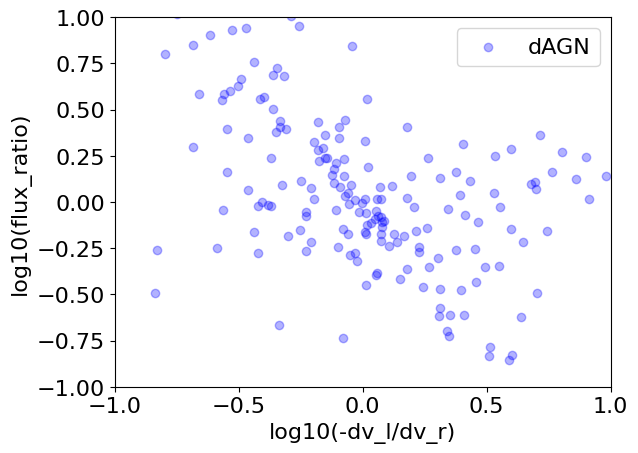

In [10]:
plt.scatter(data_x, data_y, alpha=0.3, color='blue', label='dAGN')
plt.xlabel('log10(-dv_l/dv_r)')
plt.ylabel('log10(flux_ratio)')
plt.xlim(np.log10(0.1), np.log10(10))
plt.ylim(np.log10(0.1), np.log10(10))
plt.legend()
plt.show()

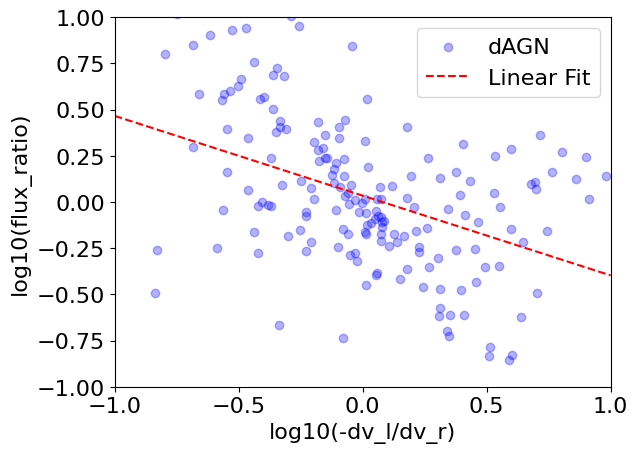

In [11]:
plt.scatter(data_x, data_y, alpha=0.3, color='blue', label='dAGN')
plt.plot(np.log10(fit_x_range), fit_y_values, color='r', linestyle='--', label='Linear Fit')
plt.xlabel('log10(-dv_l/dv_r)')
plt.ylabel('log10(flux_ratio)')
plt.xlim(np.log10(0.1), np.log10(10))
plt.ylim(np.log10(0.1), np.log10(10))
plt.legend()
plt.show()

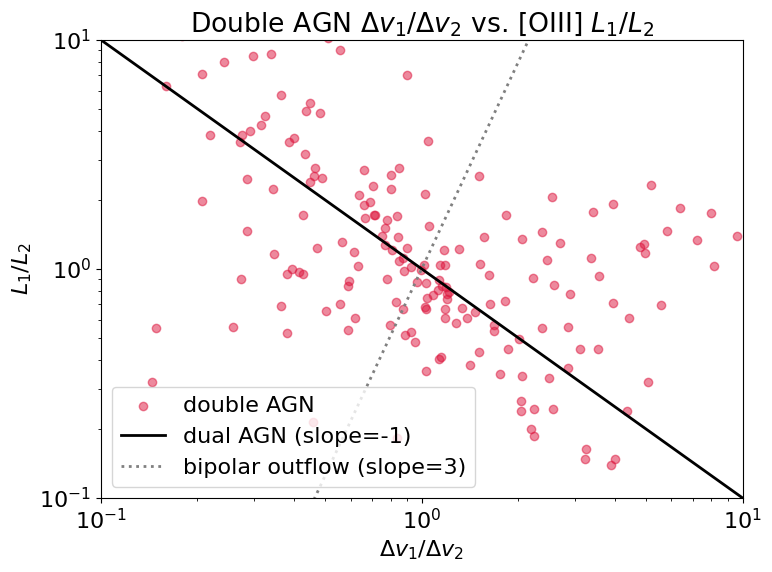

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(-dAGN_dp['DV_L']/dAGN_dp['DV_R'], dAGN_dp['flux_ratio'], alpha=0.5, color='crimson', label='double AGN')
plt.plot(x, 10**y, color='k', label='dual AGN (slope=-1)', linestyle='-', linewidth=2)
plt.plot(x, 10**y_outflow, color='gray', label='bipolar outflow (slope=3)', linestyle=':', linewidth=2)
# plt.plot(x, 10**(y_), color='gray', label='? (slope=1/3)', linestyle='--', linewidth=2)
# plt.plot(fit_x_range, 10**fit_y_values, color='r', linestyle='--', label='This work')
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=0.1, right=10)
plt.ylim(bottom=0.1, top=10)
plt.xlabel(r'$\Delta v_{1} / \Delta v_{2}$')
plt.ylabel(r'$L_{1} / L_{2}$')
plt.title(r'Double AGN $\Delta v_{1} / \Delta v_{2}$ vs. [OIII] $L_{1} / L_{2}$')
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/progress_apr/dAGN_flux_ratio_1.png')
plt.show()

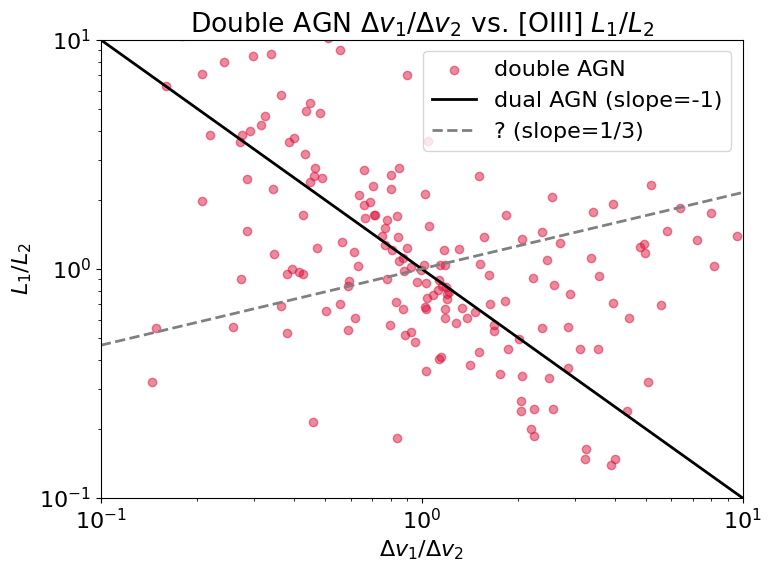

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(-dAGN_dp['DV_L']/dAGN_dp['DV_R'], dAGN_dp['flux_ratio'], alpha=0.5, color='crimson', label='double AGN')
plt.plot(x, 10**y, color='k', label='dual AGN (slope=-1)', linestyle='-', linewidth=2)
# plt.plot(x, 10**y_outflow, color='gray', label='bipolar outflow (slope=3)', linestyle=':', linewidth=2)
plt.plot(x, 10**(y_), color='gray', label='? (slope=1/3)', linestyle='--', linewidth=2)
# plt.plot(fit_x_range, 10**fit_y_values, color='r', linestyle='--', label='This work')
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=0.1, right=10)
plt.ylim(bottom=0.1, top=10)
plt.xlabel(r'$\Delta v_{1} / \Delta v_{2}$')
plt.ylabel(r'$L_{1} / L_{2}$')
plt.title(r'Double AGN $\Delta v_{1} / \Delta v_{2}$ vs. [OIII] $L_{1} / L_{2}$')
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/progress_apr/dAGN_flux_ratio_1.png')
plt.show()

In [14]:
dAGN_dp.sort_values('delta_dv', ascending=False).head(30)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,LOGSFR_1COMP,LOGSFR_2COMP,dp_count,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio
16868,39627806241460155,202.443680,0.645763,0.260044,10.133579,1.316232,2.222112e+02,-251.234451,151.977737,163.025116,...,0.553763,-0.102070,6,4.000000,0.600868,92.029999,60.984920,473.445618,1.070222,0.891507
5854,39627763858017970,196.185196,-0.906858,0.306150,10.920185,1.325015,1.192812e+02,-346.596619,268.102142,174.780945,...,0.081066,-0.161234,1,2.010492,1.394982,152.850006,48.985540,465.877777,0.656651,0.777577
16445,39627806014964884,188.788483,0.759762,0.233901,10.619380,1.104108,2.388000e+02,-185.993195,157.046387,141.843597,...,0.377205,-0.105384,6,3.290994,0.977520,177.429993,43.231460,424.793182,0.906690,0.901115
405,39627739799486898,202.019196,-1.890129,0.180293,10.764688,-4.672501,2.037141e+02,-197.337509,168.523346,149.044693,...,0.168813,-0.463270,5,6.000000,1.987401,205.649994,60.036884,401.051575,0.888425,0.879336
18961,39627812583244410,220.282761,1.121790,0.359993,10.635396,1.205440,3.075650e+02,-63.421833,131.758957,184.822662,...,0.543675,0.280271,1,4.000000,1.562244,107.110001,54.162735,370.986847,1.388899,1.971017
4565,39627757939854925,203.428696,-1.233495,0.211659,10.547485,-9.074284,1.785950e+02,-185.526047,111.998741,118.412788,...,0.016519,-0.782213,7,3.212774,0.902336,146.119995,34.879154,364.121094,1.053497,0.748625
6108,39627763988038970,203.808762,-0.930388,0.284501,10.726460,1.583882,6.983248e-22,-344.251404,76.096024,342.365326,...,-0.103454,-0.404686,3,0.500000,1.838592,399.619995,70.332280,344.251404,4.228880,10.348988
14446,39627794451271280,219.665024,0.307019,0.257635,10.509880,-0.310800,1.862124e+02,-143.034988,42.091446,173.672409,...,-1.427896,-2.230100,1,4.000000,0.968018,326.700012,57.019220,329.247375,3.443008,1.508642
7993,39627770195608357,213.784317,-0.796851,0.139104,10.604487,1.273112,1.808253e+02,-140.557739,86.652168,129.022308,...,-0.845477,-1.622280,3,3.020712,1.553470,137.169998,71.719990,321.383057,1.438883,1.627833
3967,39627757633671471,185.204071,-1.345175,0.295008,11.261312,-6.601948,2.369716e+02,-81.901810,171.835358,164.195770,...,-0.437330,-0.991977,1,2.467896,1.536521,388.959991,63.486010,318.873474,0.956735,1.162330


(0.1, 10)

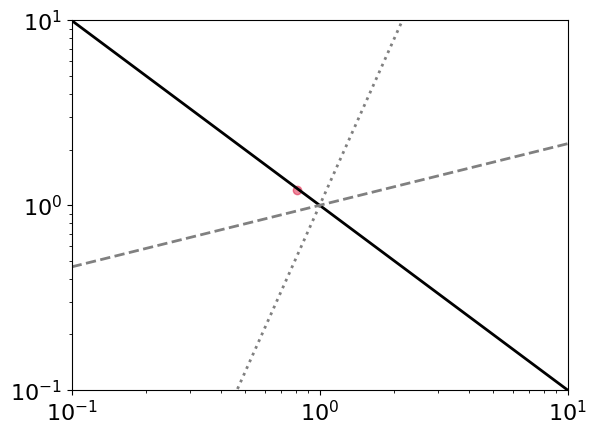

In [19]:
id = 39627782338122510
plt.scatter(-dAGN_dp[dAGN_dp['TARGETID']==id]['DV_L']/dAGN_dp[dAGN_dp['TARGETID']==id]['DV_R'], dAGN_dp[dAGN_dp['TARGETID']==id]['flux_ratio'], alpha=0.5, color='crimson', label='double AGN')
plt.plot(x, 10**y, color='k', label='dual AGN (slope=-1)', linestyle='-', linewidth=2)
plt.plot(x, 10**(y_), color='gray', label='? (slope=1/3)', linestyle='--', linewidth=2)
plt.plot(x, 10**y_outflow, color='gray', label='bipolar outflow (slope=3)', linestyle=':', linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=0.1, right=10)
plt.ylim(bottom=0.1, top=10)